# Sliding Window Decoding for Lattice Surgery Circuits

This notebook demonstrates the **extended sliding window decoder** that
supports **computation circuits** — specifically lattice surgery
merge/split operations on two rotated surface code patches.

## What's new?

The original windowed decoder (see `tutorial.ipynb`) supported only memory
experiments on a single surface code patch with one logical observable (L0).
This extension adds:

1. **Multi-observable support** — the decoder tracks L0..Ln simultaneously.
2. **Arbitrary circuit input** — any `stim.Circuit` can be decoded, not
   just `stim.Circuit.generated()` outputs.
3. **Sparse round remapping** — externally-generated circuits with
   non-consecutive detector time coordinates are handled automatically.
4. **Cross-boundary observable commitment** — correctly commits observable
   contributions for correction chains crossing the commit/buffer boundary,
   critical for codes with spacetime L-carrying error mechanisms (hook errors).

The lattice surgery circuit is generated using the **loom/eka** library,
which constructs correct merge/split circuits with intermediate data qubits
at the merge boundary.

**Prerequisites:** `pip install stim pymatching numpy matplotlib loom loom-rotated-surface-code`

In [1]:
import sys, math

sys.path.insert(0, "/Users/vishalsharma/Documents/gitrepos/Stim")
import numpy as np
import stim
import pymatching
import matplotlib.pyplot as plt
from collections import Counter

from glue.window_decoding.experiment import (
    run_full_decode,
    run_sliding_window_decode,
    run_experiment,
    print_results_table,
)
from glue.window_decoding.window_decomposition import group_detectors_by_round

## 1. Building a Lattice Surgery Circuit with Loom

We use the **loom/eka** library to construct a lattice surgery circuit on
two distance-`d` rotated surface code patches. The operations are:

1. **Reset** both patches in the `|+⟩` state
2. **Measure block syndromes** for `d` cycles (pre-merge)
3. **Merge** the two patches along a boundary (activates boundary stabilizers
   with intermediate data qubits)
4. **Measure merged syndromes** for `d` cycles
5. **Split** the merged patch back into two
6. **Measure block syndromes** for `d` cycles (post-split)
7. **Measure logical X** on both patches

The two `OBSERVABLE_INCLUDE` instructions from loom are combined into a
single observable (L0) for decoding.

In [2]:
# distance = 3
# r_pre = 4
# r_merge = 4
# r_post = 4
# noise = 0.003

# circuit = build_merge_split_circuit(
#     distance=distance,
#     r_pre=r_pre,
#     r_merge=r_merge,
#     r_post=r_post,
#     noise=noise,
# )

# print(f"Distance:       {distance}")
# print(f"Phases:         {r_pre} pre-merge + {r_merge} merge + {r_post} post-split")
# print(f"Noise:          {noise}")
# print(f"Qubits:         {circuit.num_qubits}")
# print(f"Detectors:      {circuit.num_detectors}")
# print(f"Observables:    {circuit.num_observables}")

from loom.eka import Eka, Lattice
from loom.eka.operations import (
    ResetAllDataQubits,
    Merge,
    Split,
    MeasureBlockSyndromes,
    # MeasureLogicalZ,
    MeasureLogicalX,
)
from loom.interpreter import interpret_eka
from loom_rotated_surface_code.code_factory import RotatedSurfaceCode

d = 5
lattice = Lattice.square_2d((3 * d, 3 * d))

# Create rotated surface blocks on a lattice
rsc_block_1 = RotatedSurfaceCode.create(
    d,
    d,
    lattice,
    unique_label="rsc_block_1",
)
rsc_block_2 = RotatedSurfaceCode.create(
    d, d, lattice, unique_label="rsc_block_2", position=(6, 0)
)

# Define lattice surgery operations to process
operations = (
    (
        ResetAllDataQubits(rsc_block_1.unique_label, state="+"),
        ResetAllDataQubits(rsc_block_2.unique_label, state="+"),
    ),
    (
        MeasureBlockSyndromes(rsc_block_1.unique_label, n_cycles=d),
        MeasureBlockSyndromes(rsc_block_2.unique_label, n_cycles=d),
    ),
    (Merge([rsc_block_1.unique_label, rsc_block_2.unique_label], "rsc_block_3"),),
    (MeasureBlockSyndromes("rsc_block_3", n_cycles=d),),
    (
        Split(
            "rsc_block_3",
            [rsc_block_1.unique_label, rsc_block_2.unique_label],
            split_position=d // 2,
            orientation="vertical",
        ),
    ),
    (
        MeasureBlockSyndromes(rsc_block_1.unique_label, n_cycles=d),
        MeasureBlockSyndromes(rsc_block_2.unique_label, n_cycles=d),
    ),
    (
        MeasureLogicalX("rsc_block_1"),
        MeasureLogicalX("rsc_block_2"),
    ),
)

# Interpret the operations on the rotated surface code blocks
eka_experiment = Eka(lattice, blocks=[rsc_block_1, rsc_block_2], operations=operations)
# This will contain the circuit, syndromes and detectors of the system resulting from the operations.
interpreted_eka = interpret_eka(eka_experiment)

In [3]:
from loom.executor import EkaToStimConverter, CircuitErrorModel

error_model_dep1 = CircuitErrorModel(
    circuit=interpreted_eka.final_circuit,
    error_type=("depolarizing1", 1),
    gate_error_probabilities={"h": lambda _: [0.01]},
    application_mode="after_gate",
    is_time_dependent=False,
)
error_model_dep2 = CircuitErrorModel(
    circuit=interpreted_eka.final_circuit,
    error_type=("depolarizing2", 1),
    gate_error_probabilities={
        "cx": lambda _: [0.01],
        "cz": lambda _: [0.01],
        "cnot": lambda _: [0.01],
    },
    application_mode="after_gate",
    is_time_dependent=False,
)
error_model_bitflip = CircuitErrorModel(
    circuit=interpreted_eka.final_circuit,
    error_type=("bit-flip", 1),
    gate_error_probabilities={
        "measure": lambda _: [0.01],
        "mz": lambda _: [0.01],
        "m": lambda _: [0.01],
    },
    application_mode="after_gate",
    is_time_dependent=False,
)
converter = EkaToStimConverter()
noisy_stim_circuit, quant_dict, rec_dict = converter.convert(
    interpreted_eka,
    error_models=[error_model_dep1, error_model_dep2, error_model_bitflip],
)

log1 = noisy_stim_circuit[-1]
log0 = noisy_stim_circuit[-2]
log1.targets_copy()
log0.targets_copy()
combined_log = stim.CircuitInstruction(
    "OBSERVABLE_INCLUDE",
    targets=log1.targets_copy() + log0.targets_copy(),
    gate_args=[0],
)
noisy_stim_circuit = noisy_stim_circuit[:-2]
noisy_stim_circuit.append(combined_log)

In [4]:
# Use the loom-generated circuit for all downstream analysis
circuit = noisy_stim_circuit
distance = d

print(f"Distance:       {distance}")
print(f"Qubits:         {circuit.num_qubits}")
print(f"Detectors:      {circuit.num_detectors}")
print(f"Observables:    {circuit.num_observables}")

Distance:       5
Qubits:         109
Detectors:      798
Observables:    1


In [23]:
print(noisy_stim_circuit)

QUBIT_COORDS(0.5, 0.5) 0
QUBIT_COORDS(0.5, 1.5) 1
QUBIT_COORDS(0, 1) 2
QUBIT_COORDS(0.5, 2.5) 3
QUBIT_COORDS(0.5, 3.5) 4
QUBIT_COORDS(0, 3) 5
QUBIT_COORDS(0.5, 4.5) 6
QUBIT_COORDS(1.5, 0.5) 7
QUBIT_COORDS(1.5, 1.5) 8
QUBIT_COORDS(1, 1) 9
QUBIT_COORDS(1.5, 2.5) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(1.5, 3.5) 12
QUBIT_COORDS(1, 3) 13
QUBIT_COORDS(1.5, 4.5) 14
QUBIT_COORDS(1, 4) 15
QUBIT_COORDS(1, 5) 16
QUBIT_COORDS(10.5, 0.5) 17
QUBIT_COORDS(10, 0) 18
QUBIT_COORDS(10.5, 1.5) 19
QUBIT_COORDS(10, 1) 20
QUBIT_COORDS(10.5, 2.5) 21
QUBIT_COORDS(10, 2) 22
QUBIT_COORDS(10.5, 3.5) 23
QUBIT_COORDS(10, 3) 24
QUBIT_COORDS(10.5, 4.5) 25
QUBIT_COORDS(10, 4) 26
QUBIT_COORDS(11, 2) 27
QUBIT_COORDS(11, 4) 28
QUBIT_COORDS(2.5, 0.5) 29
QUBIT_COORDS(2, 0) 30
QUBIT_COORDS(2.5, 1.5) 31
QUBIT_COORDS(2, 1) 32
QUBIT_COORDS(2.5, 2.5) 33
QUBIT_COORDS(2, 2) 34
QUBIT_COORDS(2.5, 3.5) 35
QUBIT_COORDS(2, 3) 36
QUBIT_COORDS(2.5, 4.5) 37
QUBIT_COORDS(2, 4) 38
QUBIT_COORDS(3.5, 0.5) 39
QUBIT_COORDS(3.5, 1.5) 40
QUBIT_CO

## 2. Qubit Layout Visualization

Let's visualize the spatial layout of the two surface code patches.
Qubit coordinates come from `QUBIT_COORDS` annotations in the circuit.

In [ ]:
q_coords = {}
for inst in circuit.flattened():
    if inst.name == "QUBIT_COORDS":
        q = inst.targets_copy()[0].value
        c = inst.gate_args_copy()
        q_coords[q] = (c[0], c[1])
        print(c[0] % 1)

0.5
0.5
0.0
0.5
0.5
0.0
0.5
0.5
0.5
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.0
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.5
0.5
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.5
0.5
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.5
0.5
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.5
0.5
0.0
0.5
0.0
0.5
0.0
0.5
0.0
0.0


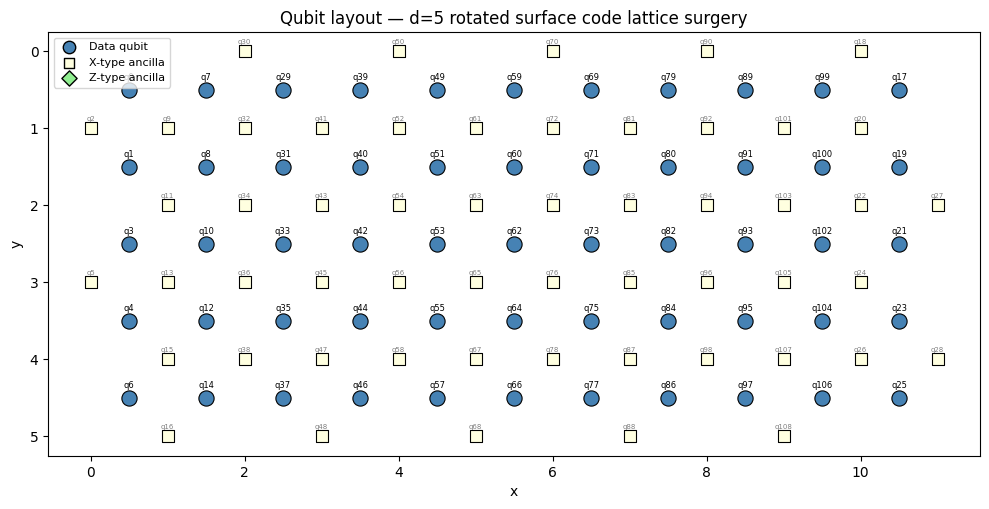

In [ ]:
# # Extract qubit coordinates from the circuit
# q_coords = {}
# data_qs = set()
# ancilla_qs = set()
# for inst in circuit.flattened():
#     if inst.name == "QUBIT_COORDS":
#         q = inst.targets_copy()[0].value
#         c = inst.gate_args_copy()
#         q_coords[q] = (c[0], c[1])
#         if c[0] % 1 == 0 and c[1] % 1 == 0:
#             ancilla_qs.add(q)
#         else:
#             data_qs.add(q)

# # Identify data vs ancilla qubits from M (final data measurement) and MR
# # for inst in circuit.flattened():
# #     if inst.name == "M":
# #         for t in inst.targets_copy():
# #             data_qs.add(t.value)
# #     if inst.name == "MR":
# #         for t in inst.targets_copy():
# #             ancilla_qs.add(t.value)

# # Identify X-type ancillas (those with H gates)
# h_qs = set()
# for inst in circuit.flattened():
#     if inst.name == "H":
#         for t in inst.targets_copy():
#             h_qs.add(t.value)

# fig, ax = plt.subplots(figsize=(10, 6))

# for q, (x, y) in q_coords.items():
#     if q in data_qs:
#         ax.scatter(
#             x, y, c="steelblue", s=120, zorder=3, edgecolors="black", linewidths=0.8
#         )
#         ax.annotate(
#             f"q{q}",
#             (x, y),
#             fontsize=6,
#             ha="center",
#             va="bottom",
#             textcoords="offset points",
#             xytext=(0, 6),
#         )
#     elif q in ancilla_qs:
#         if q in h_qs:
#             marker, color = "s", "lightyellow"  # X-type
#         else:
#             marker, color = "D", "lightgreen"  # Z-type
#         ax.scatter(
#             x,
#             y,
#             c=color,
#             s=80,
#             zorder=3,
#             edgecolors="black",
#             linewidths=0.8,
#             marker=marker,
#         )
#         ax.annotate(
#             f"q{q}",
#             (x, y),
#             fontsize=5,
#             ha="center",
#             va="bottom",
#             textcoords="offset points",
#             xytext=(0, 5),
#             color="gray",
#         )

# # Legend
# ax.scatter([], [], c="steelblue", s=80, edgecolors="black", label="Data qubit")
# ax.scatter(
#     [],
#     [],
#     c="lightyellow",
#     s=60,
#     edgecolors="black",
#     marker="s",
#     label="X-type ancilla",
# )
# ax.scatter(
#     [],
#     [],
#     c="lightgreen",
#     s=60,
#     edgecolors="black",
#     marker="D",
#     label="Z-type ancilla",
# )

# ax.set_xlabel("x")
# ax.set_ylabel("y")
# ax.set_title(f"Qubit layout — d={distance} rotated surface code lattice surgery")
# ax.legend(loc="upper left", fontsize=8)
# ax.set_aspect("equal")
# ax.invert_yaxis()
# plt.tight_layout()
# plt.show()


## 3. Detector Structure

Detectors have coordinates `(x, y, t)`. The number of detectors per round
changes across phases: fewer in the first/last rounds (boundary effects),
more during the merge phase (additional boundary stabilizers).

Externally-generated circuits may have non-consecutive time coordinates.
The decoder automatically remaps these to sequential round indices.

In [7]:
dem = circuit.detector_error_model(decompose_errors=True)
by_round = group_detectors_by_round(dem)
det_coords = dem.get_detector_coordinates()

print(f"Total detector rounds: {len(by_round)}")
print(f"Total detectors:       {circuit.num_detectors}")
print(f"{'Round (raw)':>12}  {'# Dets':>6}")
print("-" * 24)
for t in sorted(by_round.keys()):
    dets = by_round[t]
    print(f"{t:>12}  {len(dets):>6}")

Total detector rounds: 17
Total detectors:       798
 Round (raw)  # Dets
------------------------
           9      24
          17      48
          25      48
          33      48
          41      48
          50      48
          58      54
          66      54
          74      54
          82      54
          90      54
         100      48
         108      48
         116      48
         124      48
         132      48
         133      24


## 4. Space-Time Detector Visualization

We plot all detectors in the `(x, t)` plane, coloring by time.
The 2D surface code has detectors at multiple `y` coordinates, so we
project onto `x` with a slight `y` offset for visibility.

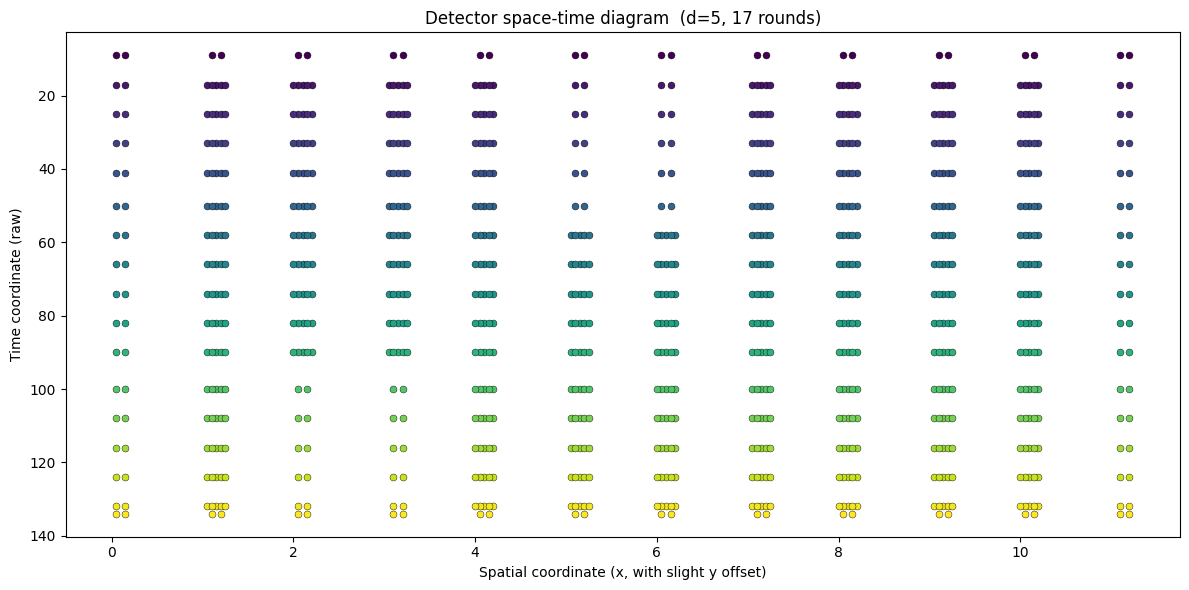

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# Color detectors by their time coordinate
times = [det_coords[d][2] for d in range(circuit.num_detectors)]
t_min, t_max = min(times), max(times)

for det_idx in range(circuit.num_detectors):
    c = det_coords[det_idx]
    x, y, t = c[0], c[1], c[2]
    # Normalize time to [0, 1] for colormap
    t_norm = (t - t_min) / (t_max - t_min) if t_max > t_min else 0.5
    color = plt.cm.viridis(t_norm)
    ax.scatter(
        x + y * 0.05,
        t,
        c=[color],
        s=25,
        zorder=3,
        edgecolors="black",
        linewidths=0.3,
    )

ax.set_xlabel("Spatial coordinate (x, with slight y offset)")
ax.set_ylabel("Time coordinate (raw)")
ax.set_title(f"Detector space-time diagram  (d={distance}, {len(by_round)} rounds)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Observable Labels in the DEM

The detector error model (DEM) labels each error mechanism with which
logical observables it affects. We also examine how many mechanisms
carry spacetime detector pairs (hook errors) — these are critical for
the sliding window decoder's cross-boundary commitment logic.

In [ ]:
obs_counts = Counter()
total_errors = 0
l_carrying_2det = 0
l_carrying_2det_spacetime = 0

for inst in dem.flattened():
    if inst.type == "error":
        total_errors += 1
        targets = inst.targets_copy()
        obs_set = set()
        det_indices = []
        for t in targets:
            if t.is_logical_observable_id():
                obs_set.add(t.val)
            if t.is_relative_detector_id():
                det_indices.append(t.val)
        if obs_set:
            obs_counts[frozenset(obs_set)] += 1
            if len(det_indices) == 2:
                l_carrying_2det += 1
                t0 = det_coords[det_indices[0]][2]
                t1 = det_coords[det_indices[1]][2]
                if t0 != t1:
                    l_carrying_2det_spacetime += 1

print(f"Total error mechanisms in DEM: {total_errors}")
print(f"\nMechanisms carrying observable labels:")
for obs_set, count in sorted(obs_counts.items(), key=lambda x: sorted(x[0])):
    labels = ", ".join(f"L{i}" for i in sorted(obs_set))
    print(f"  {labels}: {count} mechanisms")

if l_carrying_2det > 0:
    frac = l_carrying_2det_spacetime / l_carrying_2det
    print(f"\nL-carrying 2-detector mechanisms:")
    print(
        f"  Same time (spacelike):       {l_carrying_2det - l_carrying_2det_spacetime}"
    )
    print(f"  Different times (spacetime): {l_carrying_2det_spacetime}")
    print(f"  Fraction spacetime: {frac:.1%}")
    print(f"\nHook errors produce spacetime L-carrying edges that can")
    print(f"straddle the commit/buffer boundary — correctly committing")
    print(f"their observable contributions is essential.")

Total error mechanisms in DEM: 14920

Mechanisms carrying observable labels:
  L0: 1907 mechanisms

L-carrying 2-detector mechanisms:
  Same time (spacelike):       140
  Different times (spacetime): 306
  Fraction spacetime: 68.6%

Hook errors produce spacetime L-carrying edges that can
straddle the commit/buffer boundary — correctly committing
their observable contributions is essential.


## 6. Noisy Decoding: Full vs Sliding Window

Now let's decode with realistic noise and compare the full-circuit
and sliding window decoders. The error rate ratio should be close to 1.0,
confirming the windowed decoder matches the full-circuit baseline.

In [10]:
shots = 50_000
num_obs = circuit.num_observables

det_events, obs_actual, full_pred = run_full_decode(dem, shots=shots, seed=42)
sliding_pred = run_sliding_window_decode(
    dem,
    det_events,
    distance=distance,
    n_com=3,
    n_buf=4,
    num_observables=num_obs,
)

print(f"{'Observable':>10}  {'Full err':>10}  {'Sliding err':>12}  {'Ratio':>8}")
print("-" * 48)
for i in range(num_obs):
    fe = float(np.mean(full_pred[:, i] != obs_actual[:, i]))
    se = float(np.mean(sliding_pred[:, i] != obs_actual[:, i]))
    ratio = se / fe if fe > 0 else float("inf")
    print(f"{'L' + str(i):>10}  {fe:>10.6f}  {se:>12.6f}  {ratio:>8.3f}")

if num_obs > 1:
    fe_all = float(np.mean(np.any(full_pred != obs_actual, axis=1)))
    se_all = float(np.mean(np.any(sliding_pred != obs_actual, axis=1)))
    ratio_all = se_all / fe_all if fe_all > 0 else float("inf")
    print(f"{'Overall':>10}  {fe_all:>10.6f}  {se_all:>12.6f}  {ratio_all:>8.3f}")

Observable    Full err   Sliding err     Ratio
------------------------------------------------
        L0    0.249840      0.250640     1.003


## 7. Window Layout Visualization

Let's visualize how the sliding window covers the circuit.
Solid bars are commit regions; hatched bars are buffer regions.
The last window commits all remaining rounds.

Window config: n_com=3, n_buf=4
Total rounds:  17
Num windows:   5

Window 0: commit [0,3), buffer [3,7)
Window 1: commit [3,6), buffer [6,10)
Window 2: commit [6,9), buffer [9,13)
Window 3: commit [9,12), buffer [12,16)
Window 4: commit [12,17), buffer [17,17) [last]


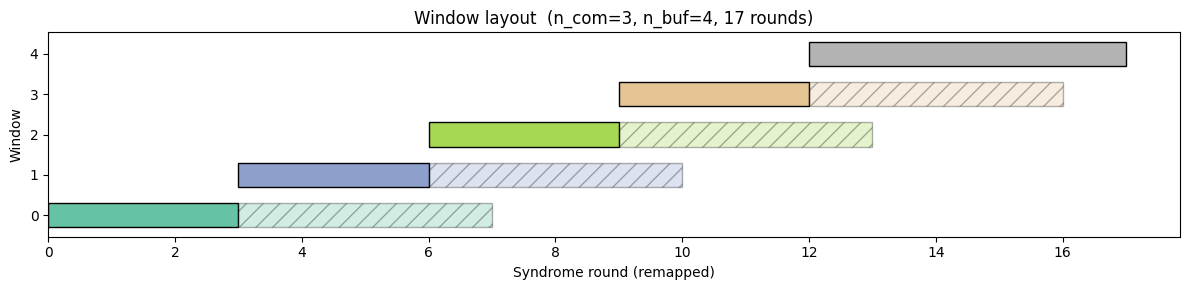

In [ ]:
n_com, n_buf = 3, 4
total_rounds = len(by_round)
num_windows = max(1, math.ceil((total_rounds - n_buf) / n_com))

print(f"Window config: n_com={n_com}, n_buf={n_buf}")
print(f"Total rounds:  {total_rounds}")
print(f"Num windows:   {num_windows}\n")

fig, ax = plt.subplots(figsize=(12, 3))
colors = plt.cm.Set2(np.linspace(0, 1, max(num_windows, 2)))

for w in range(num_windows):
    commit_start = w * n_com
    is_last = w == num_windows - 1
    commit_end = total_rounds if is_last else commit_start + n_com
    buf_end = (
        total_rounds if is_last else min(commit_start + n_com + n_buf, total_rounds)
    )

    ax.barh(
        w,
        commit_end - commit_start,
        left=commit_start,
        height=0.6,
        color=colors[w],
        edgecolor="black",
        linewidth=1,
    )
    if buf_end > commit_end:
        ax.barh(
            w,
            buf_end - commit_end,
            left=commit_end,
            height=0.6,
            color=colors[w],
            edgecolor="black",
            linewidth=1,
            alpha=0.3,
            hatch="//",
        )

    print(
        f"Window {w}: commit [{commit_start},{commit_end}), "
        f"buffer [{commit_end},{buf_end})" + (" [last]" if is_last else "")
    )

ax.set_xlabel("Syndrome round (remapped)")
ax.set_ylabel("Window")
ax.set_yticks(range(num_windows))
ax.set_title(f"Window layout  (n_com={n_com}, n_buf={n_buf}, {total_rounds} rounds)")
plt.tight_layout()
plt.show()

## 8. Robustness: Varying Window Sizes

The error rate ratio should remain near 1.0 across different
`(n_com, n_buf)` configurations. Smaller windows are more
challenging because the decoder has less context.

In [ ]:
configs = [(2, 3), (2, 4), (2, 5), (3, 3), (3, 4), (3, 5), (4, 4), (4, 5), (5, 5)]

header = f"{'n_com':>5}  {'n_buf':>5}"
for i in range(num_obs):
    header += f"  {'L' + str(i) + ' ratio':>9}"
if num_obs > 1:
    header += f"  {'Overall':>9}"
print(header)
print("-" * len(header))

for nc, nb in configs:
    sp = run_sliding_window_decode(
        dem,
        det_events,
        distance=distance,
        n_com=nc,
        n_buf=nb,
        num_observables=num_obs,
    )
    line = f"{nc:>5}  {nb:>5}"
    for i in range(num_obs):
        fe = float(np.mean(full_pred[:, i] != obs_actual[:, i]))
        se = float(np.mean(sp[:, i] != obs_actual[:, i]))
        r = se / fe if fe > 0 else float("inf")
        line += f"  {r:>9.3f}"
    if num_obs > 1:
        fe_all = float(np.mean(np.any(full_pred != obs_actual, axis=1)))
        se_all = float(np.mean(np.any(sp != obs_actual, axis=1)))
        r_all = se_all / fe_all if fe_all > 0 else float("inf")
        line += f"  {r_all:>9.3f}"
    print(line)

n_com  n_buf   L0 ratio
-----------------------
    2      3      1.033
    2      4      1.007
    2      5      1.000
    3      3      1.025
    3      4      1.003
    3      5      0.996
    4      4      1.006
    4      5      1.001
    5      5      0.999


## 9. Passing an Arbitrary Circuit to `run_experiment`

The `run_experiment` function accepts a `circuit` parameter, letting
you decode **any** Stim circuit with the sliding window decoder.
Here we pass the loom-generated circuit through the full pipeline:

In [ ]:
result = run_experiment(
    distance=distance,
    circuit=circuit,
    shots=20_000,
    n_com=4,
    n_buf=5,
    verbose=True,
)

ratio = (
    result.sliding_window_error_rate / result.full_error_rate
    if result.full_error_rate > 0
    else float("inf")
)
print(f"\nRatio: {ratio:.3f}")

## 10. Backward Compatibility: Memory Experiments Still Work

The multi-observable and sparse-round-remapping changes are fully
backward compatible. Existing memory experiment code continues to
work unchanged.

In [ ]:
mem_result = run_experiment(
    distance=3,
    num_windows=4,
    noise=0.001,
    shots=10_000,
    verbose=True,
)
ratio = (
    mem_result.sliding_window_error_rate / mem_result.full_error_rate
    if mem_result.full_error_rate > 0
    else float("inf")
)
print(f"\nMemory experiment ratio: {ratio:.3f}  (expected ~1.0)")

## Summary

This tutorial demonstrated the extended sliding window decoder for lattice
surgery circuits:

1. **Loom/eka-generated circuits** — correct merge/split construction with
   intermediate data qubits at the merge boundary.

2. **Sparse round remapping** — externally-generated circuits with
   non-consecutive detector time coordinates are automatically remapped
   to sequential indices.

3. **Windowed decoding matches full-circuit MWPM** — error rate ratios
   near 1.0 across all `(n_com, n_buf)` configurations.

4. **Hook errors** in the 2D surface code produce spacetime L-carrying
   edges. The decoder correctly commits their observable contributions;
   the closed-past-boundary rule prevents double-counting.

5. **Arbitrary circuit support** via the `circuit` parameter to
   `run_experiment`.

6. **Backward compatibility** — existing memory experiment code works
   unchanged.

### Key API

| Function | Description |
|---|---|
| `run_experiment(..., circuit=my_circuit)` | Decode an arbitrary circuit |
| `run_sliding_window_decode(..., num_observables=N)` | Multi-observable windowed decode |
| `run_full_decode(dem, shots, seed)` | Full-circuit MWPM baseline |